You might encounter an  import error with spaCy and scispaCy on the first run  due to Colab's environment. If you experience this issue, please go to 'Runtime' -> 'Restart session' and then 'Restart session and run all'. This should resolve the problem, and the code should execute correctly."

In [19]:
# 1. Base engine and dependencies
!pip install "spacy>=3.8.0,<3.9.0" scipy pydantic scikit-learn conllu joblib pysbd requests sentencepiece nmslib-metabrainz==2.1.3

# 2. scispaCy core library
!pip install --no-deps scispacy==0.5.5

! pip install gensim

# 3. Standard spaCy model
!pip install --no-deps https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

# 4. scispaCy models (0.5.4)
!pip install --no-deps https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 7.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.1.0-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 7.8 MB/s eta 0:00:00
Using cached pybind11-3.1.0-py3-none-any.whl (319 kB)
  Created wheel for nmslib-metabrainz: filename=nmslib_metabrainz-2.1.3-cp313-cp313-linux_x86_64.whl size=14530259 sha256=2f4089f97cd2959bbb16afd77538a7d18786b23b6e5d8a536195cadc739c9793
  Stored in directory: /root/.cache/pip/wheels/47/9e/8d/555ac126f08852910667a62e64c7d4c6731d7f8aa25c7571b9
Successfully built nmslib-metabrainz
  Using cached scispacy-0.5.5-py3-none-any.whl.metadata (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 167.4 MB/s eta

In [20]:
import importlib
from pathlib import Path
import spacy

models_to_fix = [
    "en_ner_bc5cdr_md"
]

# Recursively patch every config.cfg found inside each model directory
for model_name in models_to_fix:
    try:
        mod = importlib.import_module(model_name)
        root_dir = Path(mod.__file__).parent
        # rglob handles nested layouts like en_core_sci_lg-0.5.4/config.cfg
        config_files = list(root_dir.rglob("config.cfg"))

        if not config_files:
            print(f"[!] No config.cfg found for {model_name} in {root_dir}")
            continue

        for cfg_file in config_files:
            text = cfg_file.read_text()
            # Replace both double and single quotes
            updated = text.replace(
                'include_static_vectors = "True"',
                "include_static_vectors = true",
            ).replace(
                "include_static_vectors = 'True'",
                "include_static_vectors = true",
            )
            cfg_file.write_text(updated)
            print(f"[✓] Patched: {cfg_file}")
    except Exception as e:
        print(f"[!] Error processing {model_name}: {e}")

[✓] Patched: /usr/local/lib/python3.13/dist-packages/en_ner_bc5cdr_md/en_ner_bc5cdr_md-0.5.4/config.cfg


/usr/local/lib/python3.13/dist-packages/spacy/util.py:971: UserWarning: [W095] Model 'en_ner_bc5cdr_md' (0.5.4) was trained with spaCy v3.7.4 and may not be 100% compatible with the current version (3.8.16). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [21]:
import spacy
import scispacy

print(f"spaCy version: {spacy.__version__}")
print(f"scispaCy version: {scispacy.__version__}\n")

# Model names mapped to targeted biomedical test sentences
test_cases = {
    "en_ner_bc5cdr_md": (
        "Chemicals & Disease (BC5CDR)",
        "Doxorubicin administration induced acute myocardial injury and ventricular arrhythmias in cardiac tissue.",
    )
}

for model_name, (description, text) in test_cases.items():
    print(f"{'='*60}")
    print(f"Model: {model_name} ({description})")
    print(f"Input: {text}")
    print(f"{'-'*60}")
    try:
        nlp = spacy.load(model_name)
        doc = nlp(text)
        if doc.ents:
            for ent in doc.ents:
                print(f"  [{ent.label_:<14}] -> {ent.text}")
        else:
            print("  (No entities detected)")
    except Exception as e:
        print(f"  FAILED to load or run: {e}")
    print()

spaCy version: 3.8.16
scispaCy version: 0.5.5

Model: en_ner_bc5cdr_md (Chemicals & Disease (BC5CDR))
Input: Doxorubicin administration induced acute myocardial injury and ventricular arrhythmias in cardiac tissue.
------------------------------------------------------------
  [CHEMICAL      ] -> Doxorubicin
  [DISEASE       ] -> acute myocardial injury
  [DISEASE       ] -> ventricular arrhythmias



/usr/local/lib/python3.13/dist-packages/spacy/language.py:2235: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


You might encounter an  import error with spaCy and scispaCy on the first run  due to Colab's environment. If you experience this issue, please go to 'Runtime' -> 'Restart session' and then 'Restart session and run all'. This should resolve the problem, and the code should execute correctly."

# Using Spacy

In [22]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import re

from gensim.models import word2vec

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [24]:
# load headache notes
from google.colab import files
uploaded = files.upload()

Saving notes_headache.txt to notes_headache (1).txt


In [25]:
notes = []
with open('notes_headache.txt', 'r') as fin:
  lines = fin.readlines()
  for line in lines:
    notes.append(line)
print(notes)
print(len(notes))

['50 year old female presents after having fallen in the bathtub 4 days ago and hitting the back of her head. Since then she has had a massive headache" which did not resolve with Tylenol. She states that she has a high threshold for pain and did not realize how bad it was during the day while at work but then when she got home at night she noticed it. The patient noticed ""silvery spects"" in her vision and she had trouble with some simple tasks like finding the tags on the back of her clothing in the morning. She reported that she had to check several times to make sure she did not put her clothes on backwards. She has had some dizziness, but no nausea or vomiting. Her speech has not been affected.\n', '23 F with h/o Lupus, ESRD not on HD (planned PD), labile hypertension, RUE VTE on anticoagulation, recent facial swelling who presents with hypertensive emergency. Patient developed severe frontal HA last evenening, a/w nausea. BP was not [**Location (un) 1131**] on home BP cuff. In t

In [26]:
df=notes

In [27]:
# Build corpus of all the entities extracted from the notes using spaCy model.
# The corpus is an array of arrays or list of lists where each of the nested lists corresponds to a note.
corpus=[]
for row in range(0, len(df)):
  str_tokens=[]
  tokens= nlp(df[row]).ents
  for i in range(0, len(tokens)):
    str_tokens.append(tokens[i].text)
  corpus.append(list(str_tokens))


print(corpus)

[['50 year old', '4 days ago', 'Tylenol', 'the day', 'night', 'the morning'], ['23', 'ESRD', 'RUE', 'HA', 'un', '1131', '10-20', 'BP', 'BP', 'VNA', 'this past Friday', 'BP 130/70', 'CP', 'today', 'GU/GI', 'ED'], ['CAD s/p PTCA', '2', '2178', 'USOH', 'today', 'half an hour later', 'L foot', '911', 'CT', 'ICH', 'INR', '2.89', 'FFP', 'vit K 5', '10', '1', '1'], ['49 year old', 'RV', 'CHF', 'the past one year', '1016', '11-25', 'TTE', 'ASD', '121', '6', 'CHF'], ['83 year old', 'this morning', '7:45 PM', 'the day', '2171-9-25', '18'], ['72 year old', 'CAD s/p CABG x4', 'DM2', 'ED', 'aphasia', '2 minute', 'EMS', '11:28 am', 'this morning', 'SOB', '240/120, HR 124', '24', '100%', 'RA', '330', 'x3', '18', 'ED', '328', '12:20 pm', 'ED', 'ED', 'ED', 'One minute later', 'Ativan 2', '2 minutes'], ['46', '151', '2 weeks', 'two weeks', 'SOB', 'two', 'PCP', '1459', 'CT', '13x8 cm', 'SVC', '18', 'NI', '499'], ['17 year old', 'several years', 'MICU', 'UTI', '2 weeks'], ['82 year old', 'CHF', 'AAA s/p r

The vectors generated by Word2Vec, as implemented by the Gensim library, are specific to the corpus used for training. Word2Vec learns word embeddings by analyzing the patterns of word co-occurrence within the given training corpus. As a result, the learned word vectors capture the semantics and relationships of words as they appear in that particular corpus.

In other words, the word embeddings produced by Word2Vec are not universal but are context-dependent. They represent how words are related to each other within the specific textual data provided during training. Therefore, if you train a Word2Vec model on one corpus and then train another model on a different corpus, the word vectors learned by each model may differ because they reflect the linguistic patterns and context of their respective training data.

To create word vectors that are more general and applicable across different contexts, larger and more diverse training corpora are often used. Pretrained Word2Vec models, such as those trained on massive text datasets like Wikipedia or news articles, offer word vectors that are more general and can be used as a starting point for various natural language processing tasks. These pretrained embeddings capture a broad range of linguistic knowledge from diverse sources, making them useful in many applications.

In summary, Word2Vec word vectors are specific to the training corpus but can be made more universal by training on larger and more diverse datasets or by using pretrained embeddings.

In [28]:
from gensim.models import Word2Vec
model1 = Word2Vec(corpus, min_count=1)

In [29]:
model1.wv['Tylenol']

array([-6.7111817e-03, -8.6152097e-03,  8.5804518e-03, -5.5942044e-04,
       -4.1788284e-04,  2.6183010e-03,  8.0273552e-05,  8.2566477e-03,
       -9.0785604e-03, -2.9046363e-03, -2.3436337e-03, -8.7162703e-03,
        4.4026654e-03,  6.2659536e-03, -5.6984257e-03,  7.5840880e-03,
       -7.1127391e-03, -1.2452651e-03, -3.3746036e-03,  6.0087754e-03,
        8.9339763e-03,  8.0209915e-03, -2.2070606e-03, -7.4417209e-03,
       -4.4243298e-03,  7.6161013e-03,  3.2641687e-03, -9.8036155e-03,
       -6.5442091e-03, -1.9664716e-03, -5.9332978e-03, -1.3533625e-03,
        2.1557696e-03,  5.6638122e-03,  2.0690486e-03,  8.0392901e-03,
       -2.1733285e-05,  8.8567464e-03,  9.5371194e-03,  3.1080223e-03,
        7.5375233e-03,  8.1666429e-03, -8.0842813e-03,  6.0036522e-03,
        3.7124404e-03, -8.4062302e-03, -8.5176397e-03,  7.1978974e-03,
       -5.1397840e-03, -3.5556538e-03,  1.0540622e-03,  8.8104192e-05,
       -3.3136833e-04, -8.4567107e-03, -1.7033536e-03,  4.2132200e-03,
      

In [30]:
model1.wv.similar_by_word('Tylenol') #please read the below note for explaination of following output

[('UTI', 0.23739831149578094),
 ('VNA', 0.19934257864952087),
 ('2178', 0.183742493391037),
 ('this morning', 0.17763420939445496),
 ('499', 0.17435424029827118),
 ('13x8 cm', 0.17205627262592316),
 ('Dexamethasone', 0.1610460877418518),
 ('11:28 am', 0.15919293463230133),
 ('43', 0.1470787674188614),
 ('EMS', 0.14460688829421997)]

The output shows words that are not semantically similar to "Tylenol." This can happen if the training data used to train the Word2Vec model does not contain enough context or examples of the word "Tylenol" and its related terms, or if the model's parameters (such as min_count) are not set appropriately.

In this case since Tylenol appears only once in the entire corpus, min_count has to be set to 1. (The model ignores all words that appear less than min_count times)

This comes at a cost, means that even very infrequent words are included in the vocabulary. This can lead to noisy word embeddings for rare words.

In [31]:
import numpy as np

def tsne_plot(model,words, preTrained=False):
    "Creates and TSNE model and plots it"
    labels = []
    tokens = []

    for word in words:
      if preTrained:
          tokens.append(model[word])
      else:
          tokens.append(model.wv[word])
      labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(perplexity=30, early_exaggeration=12, n_components=2, init='pca', n_iter=1000, random_state=23)
    new_values = tsne_model.fit_transform(tokens)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i],y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


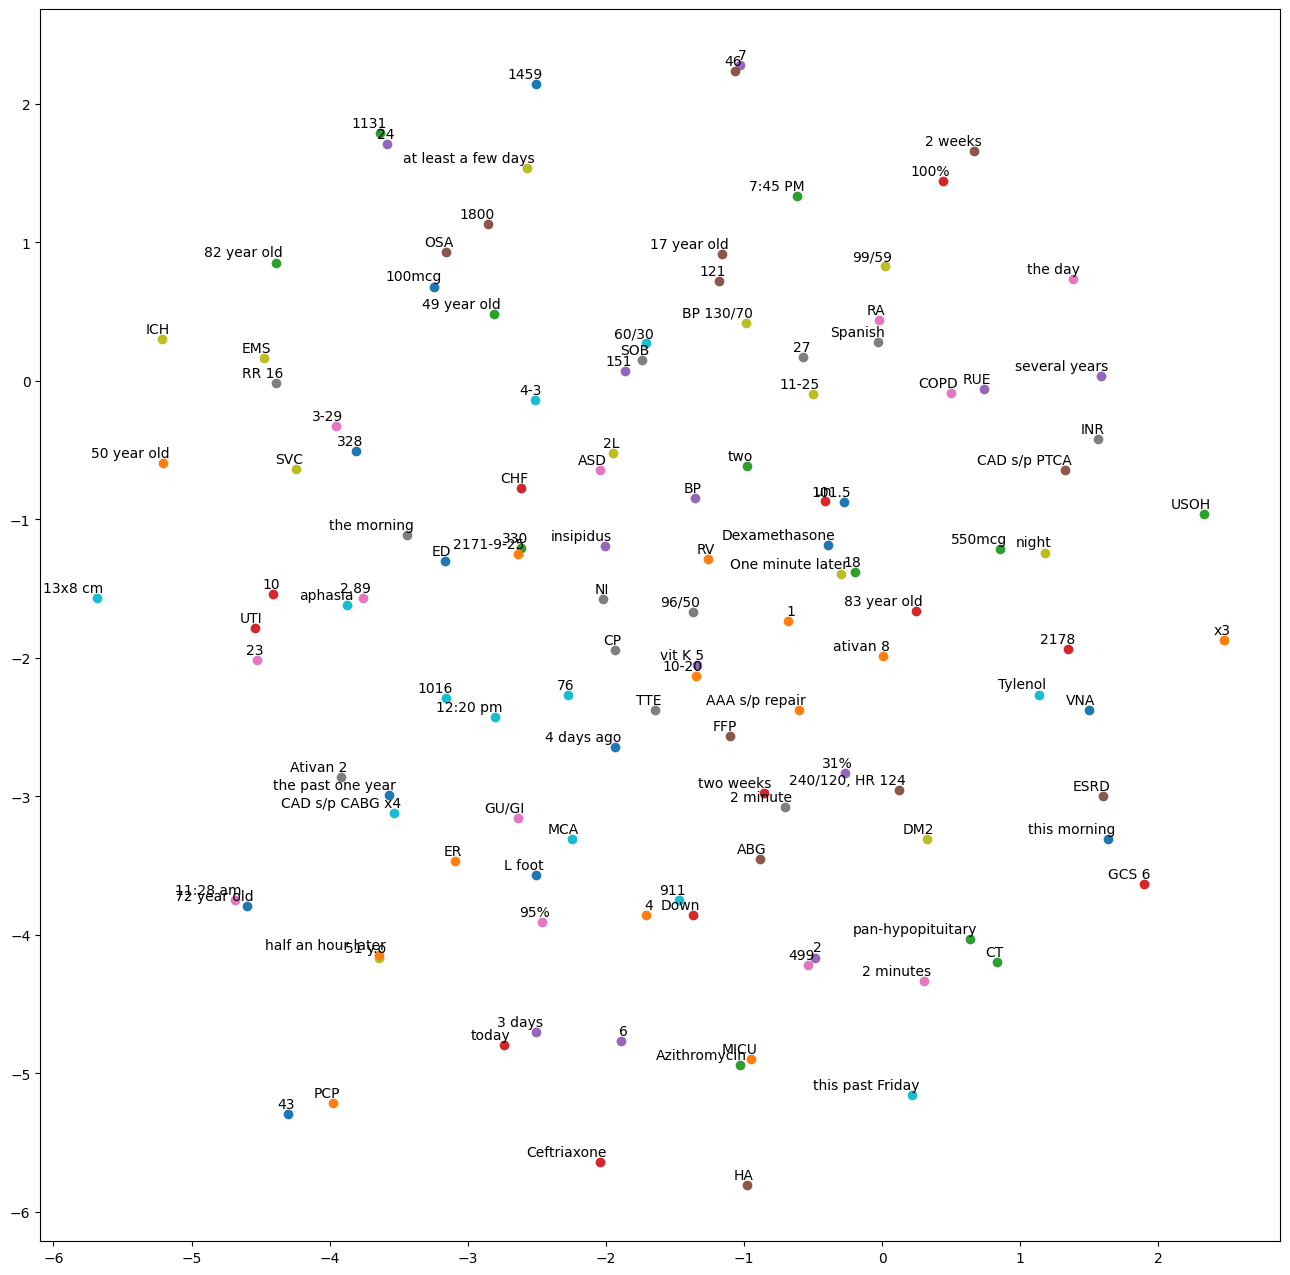

In [32]:
vocabs = model1.wv.key_to_index.keys()
new_v = np.array(list(vocabs))
tsne_plot(model1,new_v)

In [33]:
# load pre-trained word2vec embeddings
import gensim
import gensim.downloader as api

info = api.info()  # show info about available models/datasets
pretrained_model= api.load("glove-wiki-gigaword-50")  # download the model and return as object ready for use


# pretrained_model = gensim.models.KeyedVectors.load_word2vec_format('PubMed-and-PMC-ri.tar.gz', binary=True)

In [34]:
# queen = (woman+king)-man
result=pretrained_model.most_similar(positive=['woman','king'], negative=['man'], topn=1)
print(result)

[('queen', 0.8523604273796082)]


In [35]:
pretrained_model.most_similar("headache")

[('headaches', 0.8957463502883911),
 ('fatigue', 0.8547418117523193),
 ('pains', 0.8367806673049927),
 ('aches', 0.8088536262512207),
 ('nausea', 0.8022516369819641),
 ('discomfort', 0.789000391960144),
 ('pain', 0.7766653895378113),
 ('anxiety', 0.7692658305168152),
 ('symptom', 0.7564830183982849),
 ('migraine', 0.7536172866821289)]

In [36]:
corpus_in_pretrained_model = []
for word in vocabs:
  if word in pretrained_model:
    corpus_in_pretrained_model.append(word)
  else:
    print(word) #

ED
MICU
CHF
3 days
2 weeks
RA
SOB
EMS
this morning
CT
BP
HA
the day
96/50
2L
60/30
Dexamethasone
Azithromycin
Ceftriaxone
31%
ABG
95%
RR 16
99/59
ER
pan-hypopituitary
Down
OSA
COPD
Spanish
51 y.o
MCA
100mcg
ativan 8
550mcg
GCS 6
at least a few days
AAA s/p repair
82 year old
UTI
several years
17 year old
NI
SVC
13x8 cm
PCP
two weeks
2 minutes
Ativan 2
One minute later
12:20 pm
100%
240/120, HR 124
11:28 am
2 minute
DM2
CAD s/p CABG x4
72 year old
2171-9-25
7:45 PM
83 year old
ASD
TTE
the past one year
RV
49 year old
vit K 5
FFP
INR
ICH
L foot
half an hour later
USOH
2178
CAD s/p PTCA
GU/GI
CP
BP 130/70
this past Friday
VNA
RUE
ESRD
the morning
Tylenol
4 days ago
50 year old


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


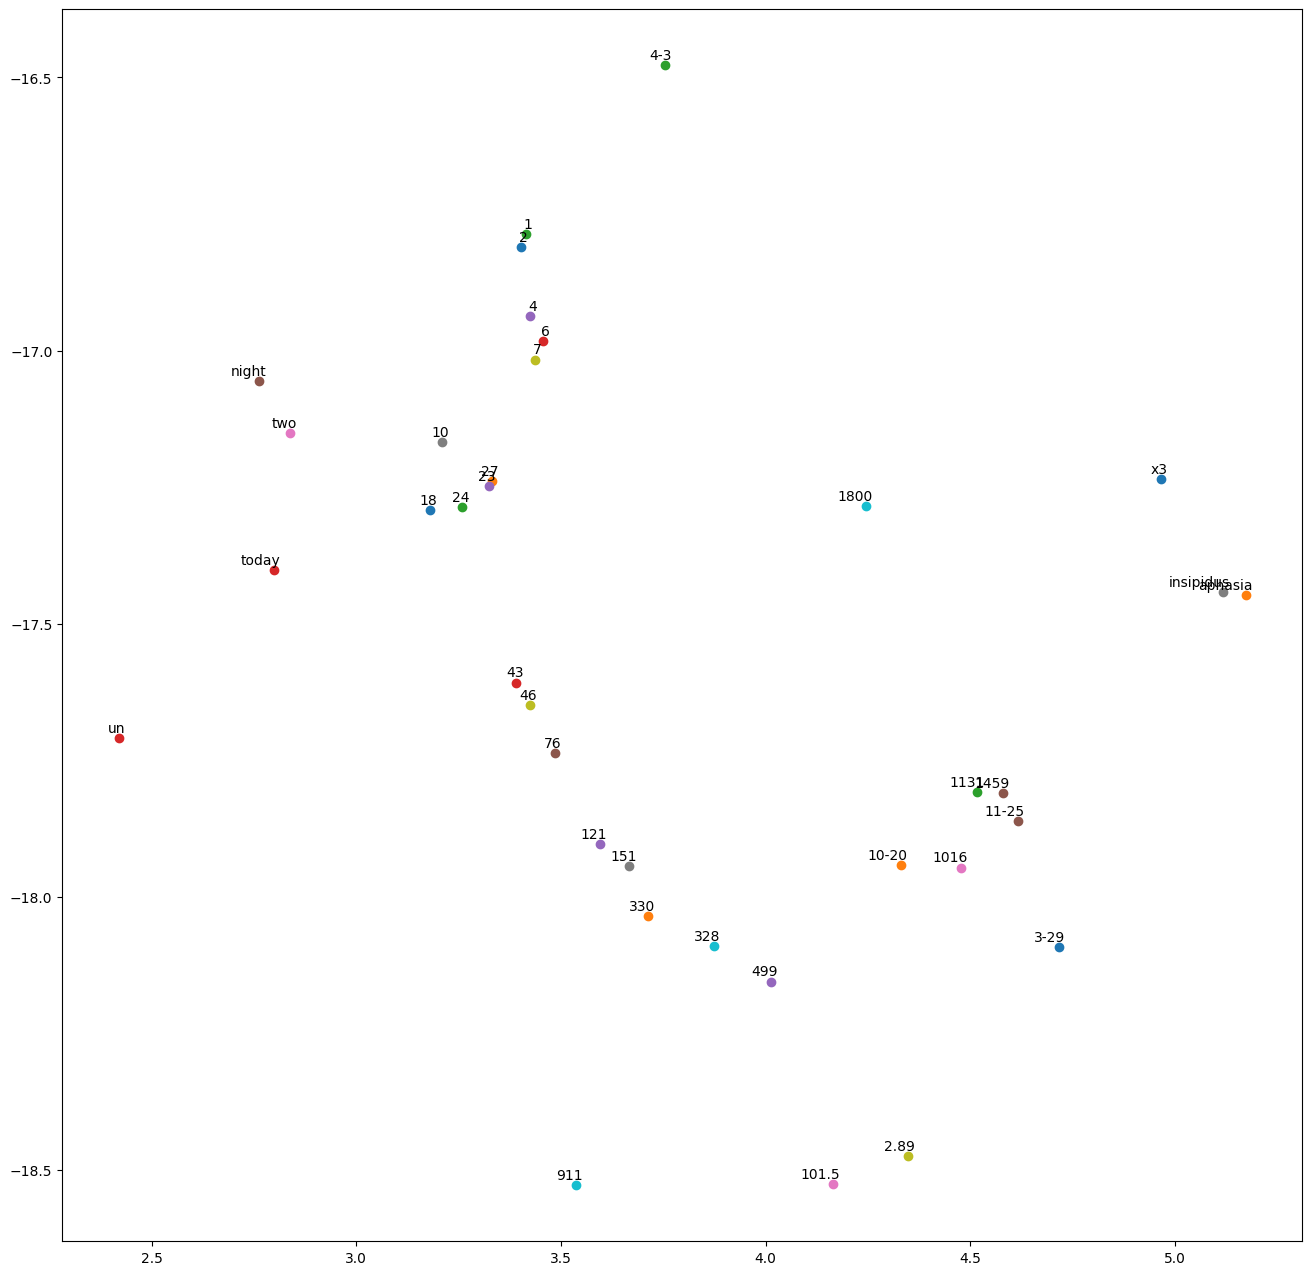

In [37]:
tsne_plot(pretrained_model,corpus_in_pretrained_model,True)

# Using SciSpacy

In [38]:
import scispacy
import spacy

nlp = spacy.load("en_ner_bc5cdr_md")

/usr/local/lib/python3.13/dist-packages/spacy/util.py:971: UserWarning: [W095] Model 'en_ner_bc5cdr_md' (0.5.4) was trained with spaCy v3.7.4 and may not be 100% compatible with the current version (3.8.16). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [39]:
notes = []
with open('notes_headache.txt', 'r') as fin:
  lines = fin.readlines()
  for line in lines:
    notes.append(line)
print(notes)
print(len(notes))

['50 year old female presents after having fallen in the bathtub 4 days ago and hitting the back of her head. Since then she has had a massive headache" which did not resolve with Tylenol. She states that she has a high threshold for pain and did not realize how bad it was during the day while at work but then when she got home at night she noticed it. The patient noticed ""silvery spects"" in her vision and she had trouble with some simple tasks like finding the tags on the back of her clothing in the morning. She reported that she had to check several times to make sure she did not put her clothes on backwards. She has had some dizziness, but no nausea or vomiting. Her speech has not been affected.\n', '23 F with h/o Lupus, ESRD not on HD (planned PD), labile hypertension, RUE VTE on anticoagulation, recent facial swelling who presents with hypertensive emergency. Patient developed severe frontal HA last evenening, a/w nausea. BP was not [**Location (un) 1131**] on home BP cuff. In t

In [40]:
df=notes

In [41]:
# Build corpus of all the entities extracted from the notes using spaCy model.
# The corpus is an array of arrays or list of lists where each of the nested lists corresponds to a note.
corpus=[]
for row in range(0, len(df)):
  str_tokens=[]
  tokens= nlp(df[row]).ents
  for i in range(0, len(tokens)):
    str_tokens.append(tokens[i].text)
  corpus.append(list(str_tokens))


print(corpus)

[['headache', 'Tylenol', 'pain', 'dizziness', 'nausea or vomiting'], ['ESRD', 'HD', 'PD', 'hypertension', 'VTE', 'swelling', 'hypertensive', 'nausea', 'nausea and vomiting yellow/green liquid', 'CP', 'shortness of breath', 'pain', 'swelling', 'dizziness', 'numbness', 'UA'], ['HTN', 'coumadin', 'CAD', 'right-sided headache', 'photophobia', 'nausea', 'numb', 'stroke', 'ICH', 'vit K', 'labetalol', 'dilantin', 'hypotension'], ['lupus, pulmonary hypertension', 'RV enlargement', 'CHF/pulm HTN', 'dyspnea', 'dyspnea', 'dyspneic', 'pulmonary hypertension', 'dilated right ventricle and R to L shunting c/w an ASD/PFO.', 'CHF'], ['aphasia', 'stroke'], ['CAD', 'hypertension', 'DM2', 'hyperlipidemia', 'CKD', 'aphasia', 'seizure', 'nystagmus', 'shakiness', 'diaphoresis', 'chest pain', 'SOB', 'nausea/vomiting', 'cough', 'FSBG', 'FSBG', 'rigors', 'Stroke', 'seizure', 'nystagmus', 'tremor', 'clonic movements', 'bowel/bladder incontinence', 'Ativan', 'seizure', 'seizure', 'stroke'], ['PCP', 'dyspnea', 'i

In [42]:
import gensim

In [43]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import re

from gensim.models import word2vec

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
model2 = word2vec.Word2Vec(corpus, min_count=1)

In [45]:
model2.wv['Tylenol']

array([-6.9575896e-03, -4.3470398e-04,  3.7045258e-03,  4.1971724e-03,
        2.4145073e-03, -9.7822249e-03,  5.5753347e-03,  1.3257859e-03,
       -4.6618269e-03,  5.9594689e-03, -1.9808030e-03, -2.3914884e-04,
       -2.6650934e-03,  4.2222124e-03, -6.8263784e-03,  7.1145650e-03,
       -4.9203732e-03, -1.6941365e-03, -8.6744428e-03, -8.6116996e-03,
       -9.2289839e-03, -5.6981212e-03,  3.0093416e-04, -9.4568273e-03,
        8.2611963e-03, -4.6520089e-03, -8.9562731e-03,  6.8045976e-03,
       -7.4452870e-03,  2.6248302e-03,  6.5757544e-03,  5.5080196e-03,
        8.9925118e-03,  5.9267734e-03, -7.1035237e-03,  3.2461211e-03,
        5.8710505e-03, -3.9612059e-03, -7.3600193e-03, -1.8447997e-03,
       -5.1892333e-04, -3.6857270e-03,  8.8868989e-03, -6.1140177e-03,
        8.9883311e-03,  4.1354136e-03, -8.0364458e-03, -7.4850926e-03,
        2.3788891e-03,  4.6255561e-03, -4.2946409e-03,  2.7114514e-03,
        8.5268216e-03,  7.6821526e-03,  2.9356475e-03, -2.2507659e-03,
      

In [46]:
model2.wv.similar_by_word('Tylenol')

[('PCP', 0.25115546584129333),
 ('dyspnea', 0.23042210936546326),
 ('fever headache', 0.22193047404289246),
 ('AAA s/p repair', 0.2204074114561081),
 ('seizure', 0.17842315137386322),
 ('fentanyl', 0.16244961321353912),
 ('dyspneic', 0.15793773531913757),
 ('desaturated', 0.15185321867465973),
 ('Azithromycin', 0.14387065172195435),
 ('nausea,', 0.14095892012119293)]

In [47]:
import numpy as np

def tsne_plot(model, words):
    "Creates a t-SNE model and plots it"
    labels = []
    tokens = []

    for word in words:
        if word in model.wv:
            tokens.append(model.wv[word])
            labels.append(word)
        else:
            print(f"Skipping '{word}' as it is not present in the model's vocabulary.")

    tsne_model = TSNE(perplexity=11, early_exaggeration=12, n_components=2, init='pca', n_iter=1000, random_state=23)
    new_values = tsne_model.fit_transform(np.array(tokens))  # Convert tokens to a NumPy array

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i], y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


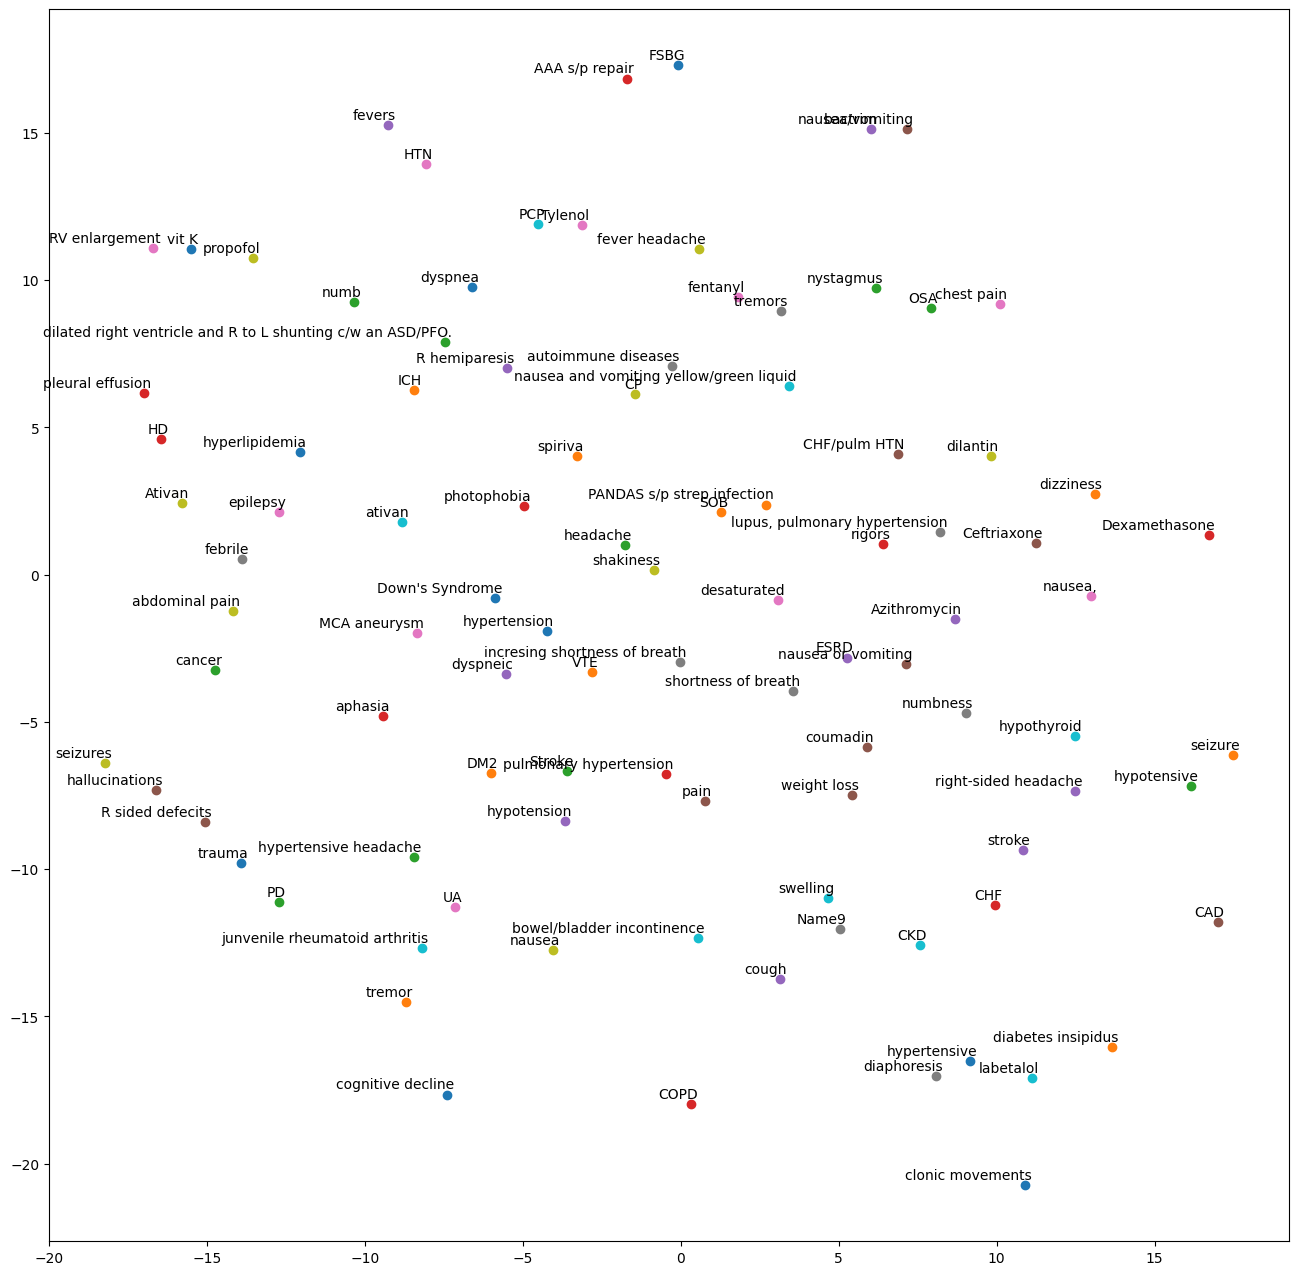

In [48]:
vocabs = model2.wv.index_to_key  # Access vocabulary using index_to_key
new_v = np.array(list(vocabs))
tsne_plot(model2, new_v)

In the above code snippet, a lot of words are skipped as the model was not trained. Hence a pretrained model will work better than the above model

In [49]:
# load pre-trained word2vec embeddings
import gensim
import gensim.downloader as api

info = api.info()  # show info about available models/datasets
pretrained_model= api.load("glove-wiki-gigaword-50")  # download the model and return as object ready for use


# model = gensim.models.KeyedVectors.load_word2vec_format('PubMed-and-PMC-ri.tar.gz', binary=True)

In [50]:
pretrained_model.most_similar("headache")

[('headaches', 0.8957463502883911),
 ('fatigue', 0.8547418117523193),
 ('pains', 0.8367806673049927),
 ('aches', 0.8088536262512207),
 ('nausea', 0.8022516369819641),
 ('discomfort', 0.789000391960144),
 ('pain', 0.7766653895378113),
 ('anxiety', 0.7692658305168152),
 ('symptom', 0.7564830183982849),
 ('migraine', 0.7536172866821289)]

In [51]:
new_corpus_in_pretrained_model = []
for word in new_v:
    if word in pretrained_model.key_to_index:
        new_corpus_in_pretrained_model.append(word)
    else:
        print(word)  # Print out-of-vocabulary words


Name9
abdominal pain
PCP
FSBG
SOB
CHF
CAD
HTN
shortness of breath
Dexamethasone
Azithromycin
Ceftriaxone
fever headache
hypothyroid
Down's Syndrome
diabetes insipidus
OSA
COPD
R hemiparesis
R sided defecits
MCA aneurysm
spiriva
hypertensive headache
AAA s/p repair
autoimmune diseases
junvenile rheumatoid arthritis
cognitive decline
PANDAS s/p strep infection
pleural effusion
weight loss
nausea,
incresing shortness of breath
Ativan
bowel/bladder incontinence
clonic movements
Stroke
nausea/vomiting
chest pain
CKD
DM2
dilated right ventricle and R to L shunting c/w an ASD/PFO.
pulmonary hypertension
dyspneic
CHF/pulm HTN
RV enlargement
lupus, pulmonary hypertension
labetalol
vit K
ICH
right-sided headache
UA
CP
nausea and vomiting yellow/green liquid
VTE
PD
HD
ESRD
nausea or vomiting
Tylenol


In [52]:
import numpy as np

def tsne_plot(model, words):
    "Creates a t-SNE model and plots it"
    labels = []
    tokens = []

    for word in words:
        if word in model:
            tokens.append(model[word])
            labels.append(word)
        else:
            print(f"Skipping '{word}' as it is not present in the model's vocabulary.")

    tsne_model = TSNE(perplexity=11, early_exaggeration=12, n_components=2, init='pca', n_iter=1000, random_state=23)
    new_values = tsne_model.fit_transform(np.array(tokens))  # Convert tokens to a NumPy array

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i], y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


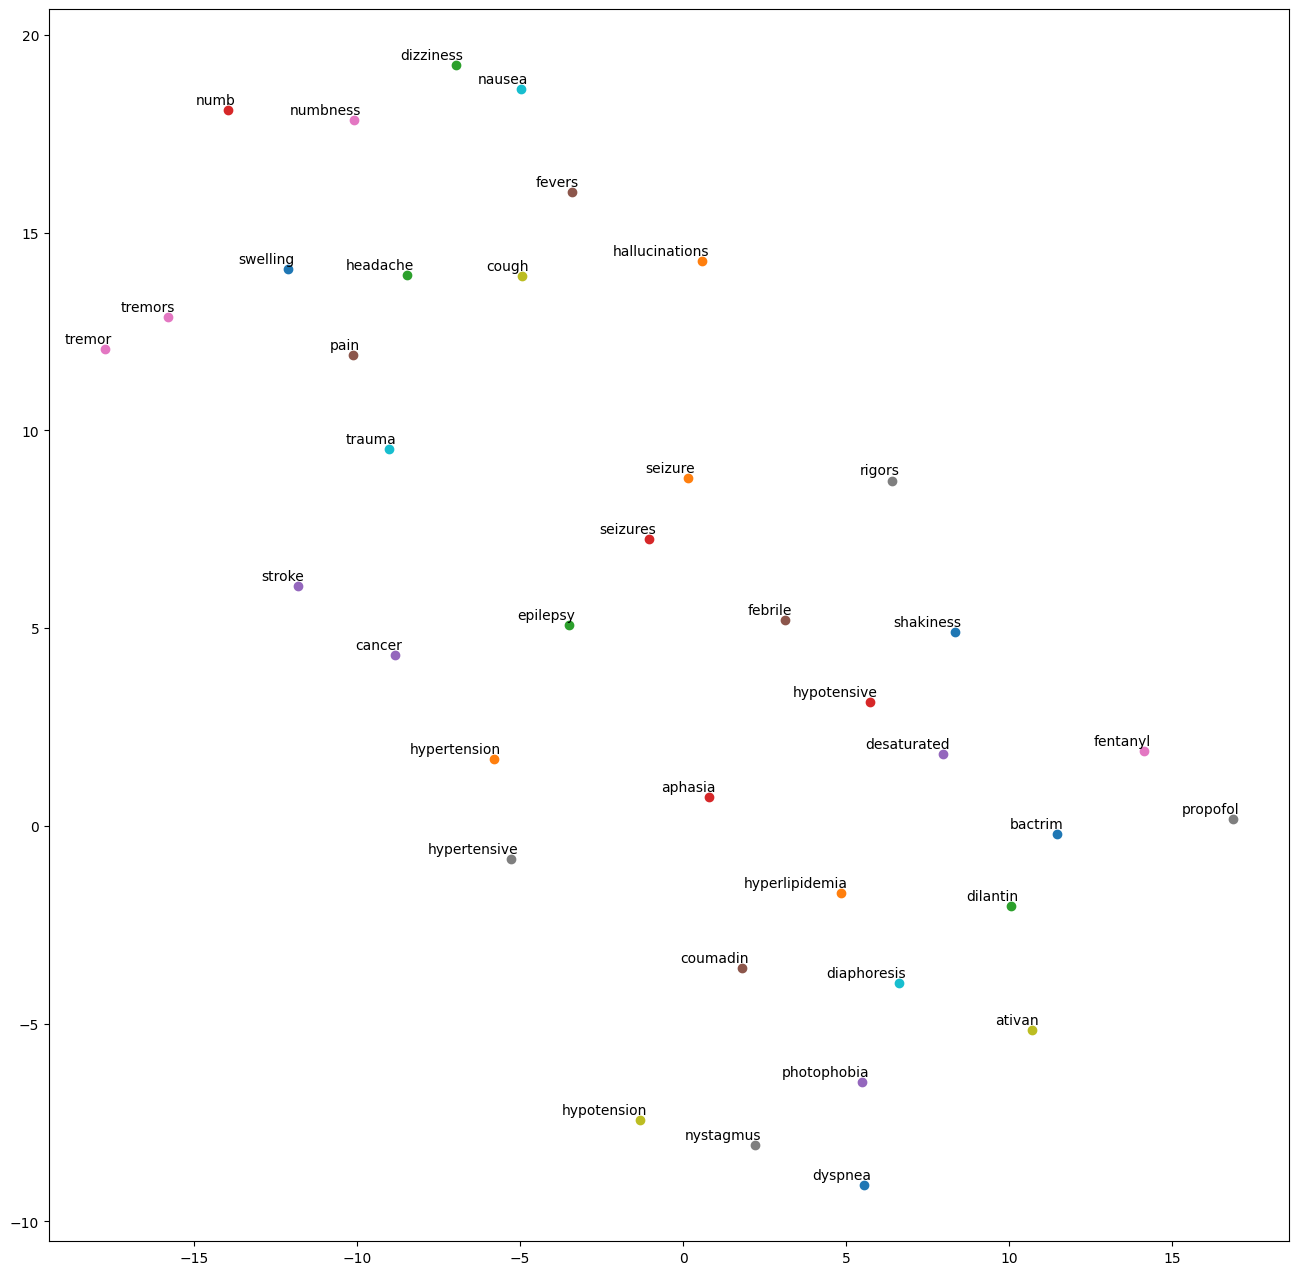

In [53]:
tsne_plot(pretrained_model,new_corpus_in_pretrained_model)